In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
general_results_path = "../data/final_test_results/summary_results.csv"
results_df = pd.read_csv(general_results_path)
results_df.head()

,EXTRACTION_MODEL,OCR_MODEL,ACCURACY,ACCURACY_STD
0,deepseek_32b,DeepseekOllama_results,0.403763,0.356681
1,deepseek_32b,Gemini_results,0.726989,0.283241
2,deepseek_32b,Gpt_5_1_medium_results,0.660860,0.290987
3,deepseek_32b,HuyuanOCR_results,0.474516,0.318183
4,deepseek_32b,Mineru2.5_results,0.610968,0.283702


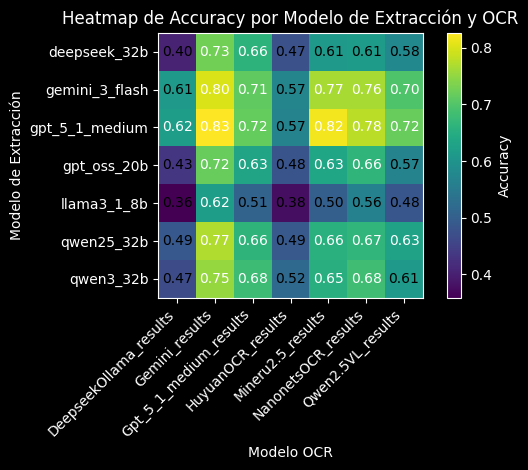

In [4]:
heatmap_df = results_df.pivot(index="EXTRACTION_MODEL", columns="OCR_MODEL", values="ACCURACY")

# Plot heatmap
plt.figure()
plt.imshow(heatmap_df)
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.colorbar(label="Accuracy")


for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        if not pd.isna(value):
            plt.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > heatmap_df.values.mean() else "black"
            )


plt.title("Heatmap de Accuracy por Modelo de Extracción y OCR")
plt.xlabel("Modelo OCR")
plt.ylabel("Modelo de Extracción")
plt.tight_layout()
plt.show()

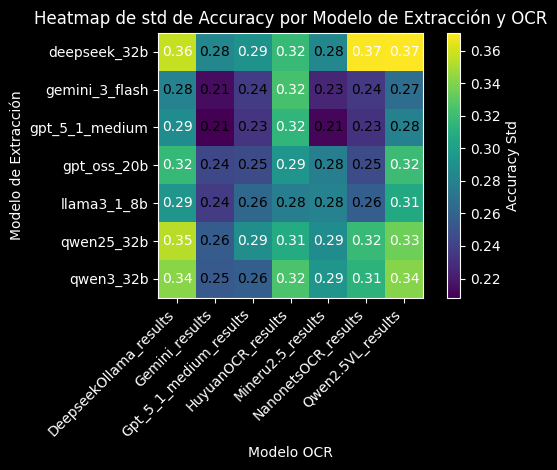

In [27]:
heatmap_df = results_df.pivot(index="EXTRACTION_MODEL", columns="OCR_MODEL", values="ACCURACY_STD")

# Plot heatmap
plt.figure()
plt.imshow(heatmap_df)
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45, ha="right")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.colorbar(label="Accuracy Std")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        if not pd.isna(value):
            plt.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white" if value > heatmap_df.values.mean() else "black"
            )
plt.title("Heatmap de std de Accuracy por Modelo de Extracción y OCR")
plt.xlabel("Modelo OCR")
plt.ylabel("Modelo de Extracción")
plt.tight_layout()
plt.show()


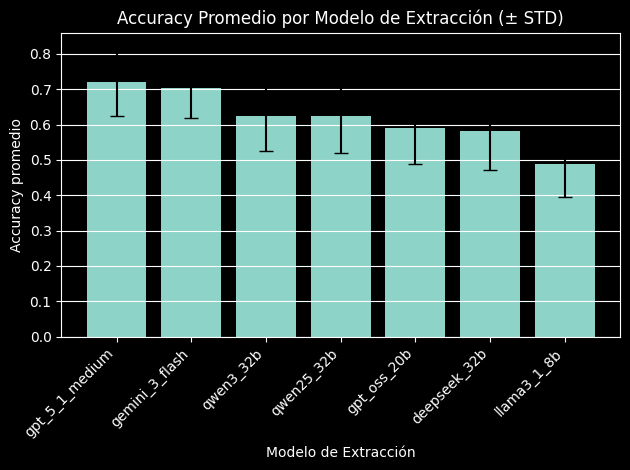

In [28]:
stats = (
    results_df
    .groupby("EXTRACTION_MODEL")["ACCURACY"]
    .agg(mean="mean", std="std")
    .sort_values("mean", ascending=False)
)

plt.figure()
plt.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

plt.title("Accuracy Promedio por Modelo de Extracción (± STD)")
plt.xlabel("Modelo de Extracción")
plt.ylabel("Accuracy promedio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


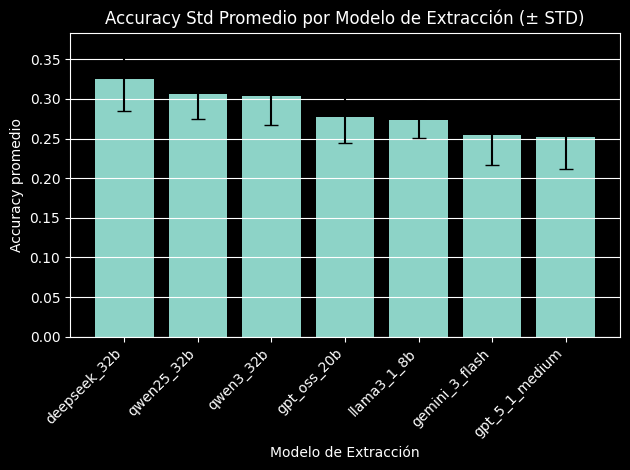

In [29]:
stats = (
    results_df
    .groupby("EXTRACTION_MODEL")["ACCURACY_STD"]
    .agg(mean="mean", std="std")
    .sort_values("mean", ascending=False)
)

plt.figure()
plt.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

plt.title("Accuracy Std Promedio por Modelo de Extracción (± STD)")
plt.xlabel("Modelo de Extracción")
plt.ylabel("Accuracy promedio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()



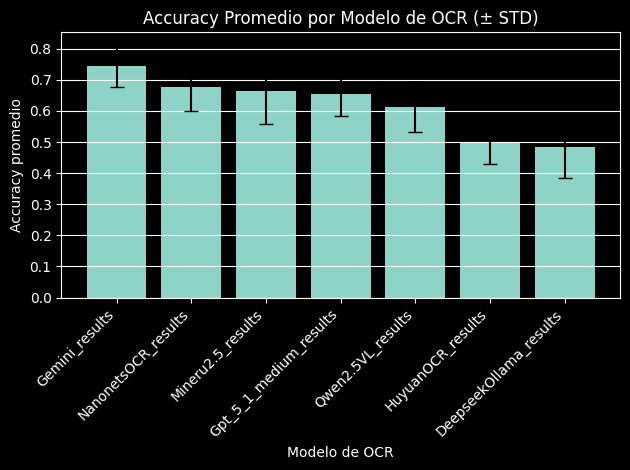

In [30]:
stats = (
    results_df
    .groupby("OCR_MODEL")["ACCURACY"]
    .agg(mean="mean", std="std")
    .sort_values("mean", ascending=False)
)

plt.figure()
plt.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

plt.title("Accuracy Promedio por Modelo de OCR (± STD)")
plt.xlabel("Modelo de OCR")
plt.ylabel("Accuracy promedio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


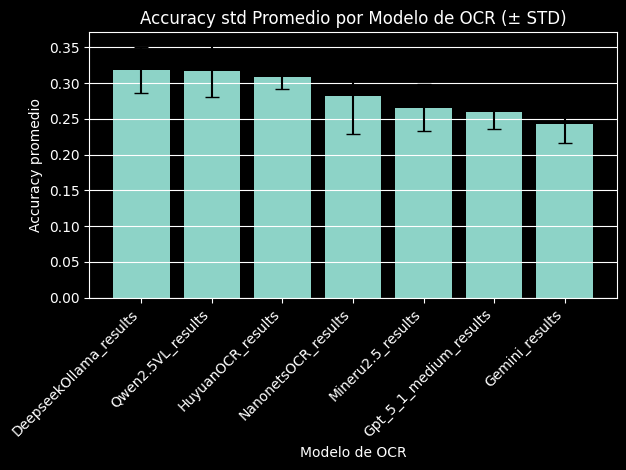

In [31]:
stats = (
    results_df
    .groupby("OCR_MODEL")["ACCURACY_STD"]
    .agg(mean="mean", std="std")
    .sort_values("mean", ascending=False)
)

plt.figure()
plt.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],
    capsize=5
)

plt.title("Accuracy std Promedio por Modelo de OCR (± STD)")
plt.xlabel("Modelo de OCR")
plt.ylabel("Accuracy promedio")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

